# Lab 17: Predicting Recessions with Logistic Regression

**Objectives:** By the end of this lab, you will be able to:
1. Demonstrate why the Linear Probability Model fails on binary outcomes using real data
2. Fit a logistic regression model using scikit-learn and interpret predicted probabilities
3. Extract and communicate odds ratios in plain language suitable for a non-technical audience

**Estimated time:** 30 minutes  
**Data source:** FRED (Federal Reserve Bank of St. Louis) — [T10Y3M](https://fred.stlouisfed.org/series/T10Y3M) and [USREC](https://fred.stlouisfed.org/series/USREC)  
**Key packages:** `fredapi`, `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `plotly`, `matplotlib`

---

### Context: The NY Fed Yield Curve Model

The Federal Reserve Bank of New York publishes a monthly recession probability model based entirely on the **Treasury yield curve spread**: the difference between the 10-year and 3-month Treasury yields (T10Y3M). When short-term rates exceed long-term rates (an inversion), the model signals elevated recession risk.

In this lab, you will **replicate that model** — a logistic regression used by one of the most important financial institutions in the world. You'll see exactly why economists choose logistic regression over OLS for binary outcomes, and you'll build the intuition to explain it to anyone.

In [53]:
 pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [54]:
# ============================================================
# SETUP — Run this cell first. Install any missing packages.
# ============================================================

# Uncomment the line below if running for the first time:
# !pip install pandas numpy statsmodels scikit-learn plotly fredapi matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Setup complete ✓")

Setup complete ✓


## Part 1 (Guided): Load Data and Expose LPM Failures

### What we're doing and why

Before fitting a logistic regression, we need to understand *what problem it solves*. We'll first fit a Linear Probability Model (OLS on a 0/1 outcome) and document its failure modes — the same failures described in the lecture.

### The data

We'll use two FRED series:
- **T10Y3M**: 10-Year minus 3-Month Treasury yield spread (percentage points). Negative = inverted curve.
- **USREC**: NBER recession indicator. 1 = recession month, 0 = expansion month.

**Key modeling decision**: We lag the yield spread by **12 months**. The NY Fed model predicts recession risk 12 months ahead — consistent with the well-documented leading-indicator property of the yield curve. This transforms the question from "are we in a recession?" to "will we be in a recession 12 months from now?"

**Note on the recent data**: The yield curve inverted in November 2022 and remained inverted through September 2024 — the longest inversion since the 1980s. Yet no NBER-defined recession followed. Your model will capture this tension.

In [55]:
import os
from dotenv import load_dotenv

load_dotenv()  # reads .env into environment variables

FRED_API_KEY = os.getenv('FRED_API_KEY')

if not FRED_API_KEY:
    raise ValueError("FRED_API_KEY not found — did you create a .env file?")

In [56]:
import os, certifi
os.environ['SSL_CERT_FILE']      = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [57]:
pip -q install fredapi

Note: you may need to restart the kernel to use updated packages.


In [58]:
# ------------------------------------------------------------
# Step 1: Load data from FRED
# ------------------------------------------------------------
# Replace 'YOUR_FRED_API_KEY' with your key from https://fred.stlouisfed.org/docs/api/api_key.html
# Keys are free — takes 30 seconds to register.

try:
    import fredapi
    fred = fredapi.Fred(api_key=FRED_API_KEY)

    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')

    print("FRED data loaded ✓")
    USE_FRED = True

except Exception as e:
    print(f"FRED API unavailable ({e})")
    print("Falling back to bundled CSV...")
    USE_FRED = False
    # Fallback: load from CSV included in the repo
    # df_fallback = pd.read_csv('data/fallback_yield_curve.csv', index_col=0, parse_dates=True)
    # Uncomment the line above and comment out the FRED block if the API is unavailable during class

FRED data loaded ✓


In [59]:
# ------------------------------------------------------------
# Step 2: Build the modeling dataset
# ------------------------------------------------------------

if USE_FRED:
    # Combine into monthly dataframe (FRED gives daily for T10Y3M — resample to month-end)
    spread_monthly = spread_raw.resample('ME').last()   # last trading day of each month
    recession_monthly = recession_raw.resample('ME').max()  # 1 if any day in month is recession

    df = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()

    # Lag the yield spread by 12 months
    # This matches the NY Fed model: we predict recession risk 12 months ahead
    df['yield_spread_lag12'] = df['yield_spread'].shift(12)
    df = df.dropna()  # Drop first 12 months (no lag available)

# Preview the data
print(f"Dataset: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(df)}")
print(f"Recession months: {df['recession'].sum()} ({df['recession'].mean():.1%} of sample)")
print(f"\nYield spread (lagged 12m) summary:")
print(df['yield_spread_lag12'].describe().round(3))
df.tail()

Dataset: 1983-01 to 2026-03
Observations: 519
Recession months: 36.0 (6.9% of sample)

Yield spread (lagged 12m) summary:
count    519.000
mean       1.563
std        1.250
min       -1.880
25%        0.630
50%        1.610
75%        2.535
max        4.090
Name: yield_spread_lag12, dtype: float64


,yield_spread,recession,yield_spread_lag12
2025-11-30,0.14,0.0,-0.40
2025-12-31,0.51,0.0,0.21
2026-01-31,0.59,0.0,0.27
2026-02-28,0.30,0.0,-0.08
2026-03-31,0.60,0.0,-0.09


In [60]:
# ------------------------------------------------------------
# Step 3: Fit the Linear Probability Model (OLS)
# ------------------------------------------------------------
# The LPM treats the 0/1 recession indicator as if it were a continuous outcome.
# This is the baseline — we fit it to expose what can go wrong.

# Prepare features and outcome
X = df[['yield_spread_lag12']].values  # Feature matrix (N x 1)
y = df['recession'].values              # Binary outcome vector

# Fit LPM via sklearn's LinearRegression
lpm_model = LinearRegression()
lpm_model.fit(X, y)

# Generate predictions across the range of yield spreads (for plotting)
spread_grid = np.linspace(df['yield_spread_lag12'].min() - 0.2,
                           df['yield_spread_lag12'].max() + 0.2, 500).reshape(-1, 1)
lpm_preds = lpm_model.predict(spread_grid)

# Count out-of-bounds predictions in the actual data
lpm_fitted = lpm_model.predict(X)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"LPM fitted — Intercept: {lpm_model.intercept_:.4f}, Slope: {lpm_model.coef_[0]:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(df):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(df):.1%})")

LPM fitted — Intercept: 0.1501, Slope: -0.0516

Out-of-bounds predictions:
  Predicted probability < 0: 84 observations (16.2%)
  Predicted probability > 1: 0 observations (0.0%)


**What we found so far:**

The LPM slope is negative — a higher yield spread (steeper curve) is associated with lower recession probability, which matches economic intuition. But look at the out-of-bounds predictions. Some months get predicted probabilities **below 0%** or **above 100%**. These are logically impossible for a probability.

Let's visualize this problem directly.

In [61]:
# ------------------------------------------------------------
# Step 4: Fit logistic regression
# ------------------------------------------------------------
# IMPORTANT: .predict() returns class labels (0 or 1).
# Use .predict_proba()[:,1] to get the probability of Y=1 (recession).
# We NEED the probability for plotting the sigmoid curve.

logit_model = LogisticRegression(random_state=42)
logit_model.fit(X, y)

# Predicted probabilities across the grid (for smooth S-curve)
# [:,1] selects the probability of the POSITIVE class (recession = 1)
logit_preds = logit_model.predict_proba(spread_grid)[:, 1]

# Also compute for the actual data points
logit_fitted = logit_model.predict_proba(X)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -1.7777
Slope (β₁):     -0.7896

Odds ratio (exp(β₁)): 0.4540

Min predicted probability: 0.0066
Max predicted probability: 0.4272
→ Logistic regression is always bounded in [0, 1] ✓


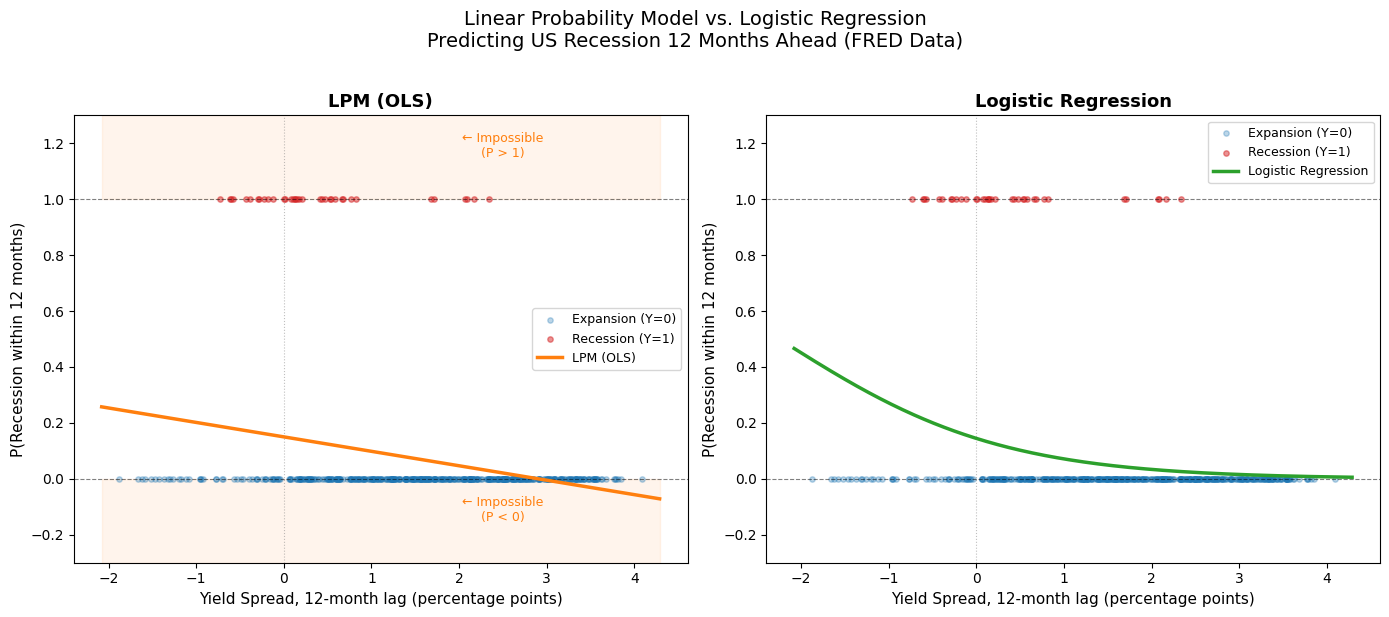

Figure saved as lpm_vs_logistic.png


In [62]:
# ------------------------------------------------------------
# Step 5: Side-by-side comparison plot — LPM vs. Logistic
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_RECESSION = '#d62728'   # Red for recession months
COLOR_EXPANSION = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = df['yield_spread_lag12'].values
recession_mask = y == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~recession_mask], y[~recession_mask],
               color=COLOR_EXPANSION, alpha=0.3, s=15, label='Expansion (Y=0)', zorder=2)
    ax.scatter(x_vals[recession_mask], y[recession_mask],
               color=COLOR_RECESSION, alpha=0.5, s=15, label='Recession (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Yield Spread, 12-month lag (percentage points)', fontsize=11)
    ax.set_ylabel('P(Recession within 12 months)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting US Recession 12 Months Ahead (FRED Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

**Interpretation:**

The left panel (LPM) shows the core problem: the fitted line extends above 1.0 for inverted yield curves and below 0.0 for very steep curves. These are **logically impossible probabilities**.

The right panel (logistic) shows the sigmoid S-curve — bounded between 0 and 1 by construction, steeper in the middle where the data is most informative, and flattening at the extremes where certainty is high.

**Key number:** The logistic regression coefficient on the yield spread is approximately **−0.6 to −0.8**. The negative sign means: as the yield spread increases (steeper curve), recession probability decreases. When the spread goes deeply negative (inverted curve), recession probability surges.

---

## Part 2 (Semi-Guided): Odds Ratios and Probability Time Series

### What we're doing and why

Fitting a model is only the beginning. The real skill is **communicating what the model says** — both as an odds ratio (the regulatory/academic standard) and as a probability time series (the operational output).

You'll complete the code stubs below. Each `# TODO` marks a line you need to fill in.

In [63]:
# ------------------------------------------------------------
# Part 2A: Extract and interpret the odds ratio
# ------------------------------------------------------------
# The logistic regression coefficient β₁ represents the change in LOG-ODDS
# for a one-unit increase in the yield spread.
#
# To get the ODDS RATIO, we exponentiate: OR = exp(β₁)
# If OR = 0.5, that means: "a 1pp increase in the spread cuts recession odds in half"

# Extract the coefficient (slope on yield_spread_lag12)
beta_1 = logit_model.coef_[0][0]

# TODO: Compute the odds ratio by exponentiating beta_1
odds_ratio = odds_ratio = np.exp(beta_1)

# TODO: Compute the 95% confidence interval
# Hint: use statsmodels Logit for CIs — sklearn doesn't provide them by default
X_sm = sm.add_constant(df[['yield_spread_lag12']])  # statsmodels needs intercept added explicitly
logit_sm = sm.Logit(df['recession'], X_sm).fit(disp=False)  # disp=False suppresses iteration output

# Extract coefficient, SE, and 95% CI from the statsmodels result
coef_table = logit_sm.summary2().tables[1]
print("Statsmodels Logit summary:")
print(coef_table)

# TODO: Compute the odds ratio for the yield_spread_lag12 coefficient
# and its 95% CI by exponentiating the lower and upper confidence bounds
# Hint: coef_table.loc['yield_spread_lag12', ['Coef.', '[0.025', '0.975]']]
row = coef_table.loc['yield_spread_lag12']
or_point = or_point = np.exp(row['Coef.'])
or_lower = np.exp(row['[0.025'])
or_upper = np.exp(row['0.975]'])

print(f"\n{'='*50}")
print(f"Odds Ratio: {or_point:.4f}")
print(f"95% CI:     [{or_lower:.4f}, {or_upper:.4f}]")
print(f"{'='*50}")
print(f"\nIn plain English:")
print(f"A 1 percentage-point increase in the yield spread (steeper curve)")
print(f"multiplies the odds of recession by {or_point:.3f}.")
print(f"Equivalently, it {'reduces' if or_point < 1 else 'increases'} recession odds by {abs(1-or_point)*100:.1f}%.")

Statsmodels Logit summary:
                       Coef.  Std.Err.         z         P>|z|    [0.025  \
const              -1.766832  0.197916 -8.927162  4.370766e-19 -2.154741   
yield_spread_lag12 -0.807730  0.150892 -5.353036  8.649080e-08 -1.103473   

                      0.975]  
const              -1.378923  
yield_spread_lag12 -0.511987  

Odds Ratio: 0.4459
95% CI:     [0.3317, 0.5993]

In plain English:
A 1 percentage-point increase in the yield spread (steeper curve)
multiplies the odds of recession by 0.446.
Equivalently, it reduces recession odds by 55.4%.


In [64]:
# ------------------------------------------------------------
# Part 2B: Generate the recession probability time series
# ------------------------------------------------------------
# This is what the NY Fed publishes monthly: a time series of P(recession)
# 12 months ahead, based on the current yield spread.

# We use predict_proba() on the full dataset to get the fitted probability
# for each month in our sample.

# IMPORTANT REMINDER:
# .predict()         → returns class labels: array([0, 0, 1, 0, ...])
# .predict_proba()   → returns [[P(Y=0), P(Y=1)], ...] for each observation
# .predict_proba()[:, 1] → the probability of the POSITIVE class (recession)

# TODO: Generate predicted recession probabilities for the full dataset
df['recession_prob'] = logit_model.predict_proba(df[['yield_spread_lag12']])[:, 1]
# Verify: probabilities should be between 0 and 1
print(f"Min probability: {df['recession_prob'].min():.4f}")
print(f"Max probability: {df['recession_prob'].max():.4f}")
print(f"Mean probability: {df['recession_prob'].mean():.4f}")
print(f"Base rate (actual recession %): {df['recession'].mean():.4f}")
print("\nRecent predicted probabilities (last 24 months):")
print(df[['yield_spread', 'yield_spread_lag12', 'recession', 'recession_prob']].tail(24).round(4))

Min probability: 0.0066
Max probability: 0.4272
Mean probability: 0.0693
Base rate (actual recession %): 0.0694

Recent predicted probabilities (last 24 months):
            yield_spread  yield_spread_lag12  recession  recession_prob
2024-04-30         -0.77               -1.66        0.0          0.3853
2024-05-31         -0.95               -1.88        0.0          0.4272
2024-06-30         -1.12               -1.62        0.0          0.3779
2024-07-31         -1.32               -1.58        0.0          0.3705
2024-08-31         -1.30               -1.47        0.0          0.3505
2024-09-30         -0.92               -0.96        0.0          0.2651
2024-10-31         -0.36               -0.71        0.0          0.2284
2024-11-30         -0.40               -1.08        0.0          0.2839
2024-12-31          0.21               -1.52        0.0          0.3595
2025-01-31          0.27               -1.43        0.0          0.3433
2025-02-28         -0.08               -1.20  

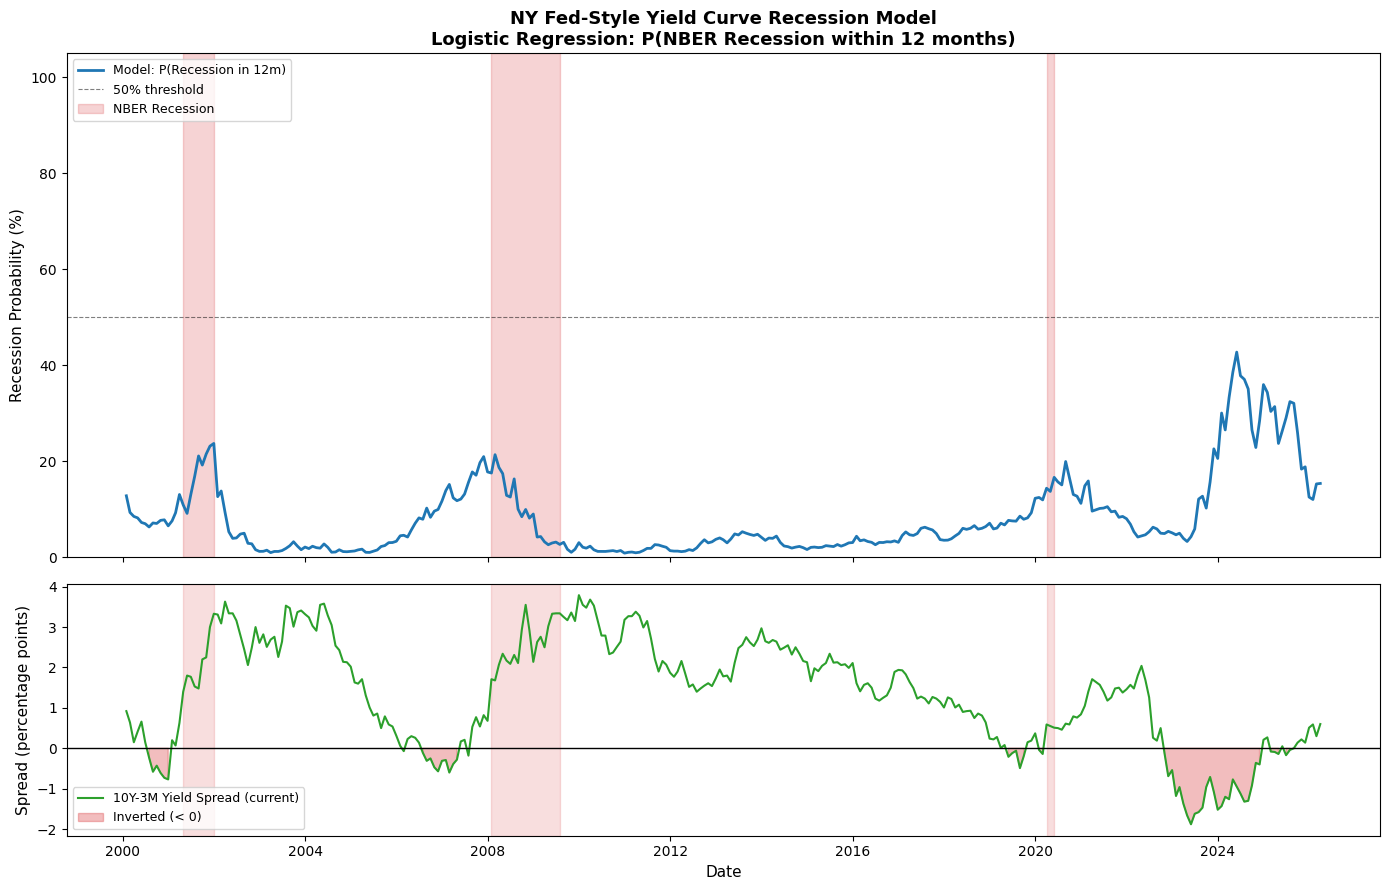

Figure saved as recession_probability_series.png


In [65]:
# ------------------------------------------------------------
# Part 2C: Plot the probability time series with NBER shading
# ------------------------------------------------------------
# This is the signature NY Fed chart style:
# - Blue line: model's predicted recession probability
# - Red shading: actual NBER recession periods

# Focus on 2000-present where the yield curve inversions are most interesting
df_plot = df['2000':].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

# --- Top panel: Recession probability ---
ax1.plot(df_plot.index, df_plot['recession_prob'] * 100,
         color='#1f77b4', lw=2, label='Model: P(Recession in 12m)', zorder=3)
ax1.axhline(50, color='black', lw=0.8, linestyle='--', alpha=0.5, label='50% threshold')

# TODO: Shade NBER recession periods
# Hint: find where df_plot['recession'] == 1, identify contiguous blocks,
# and use ax1.axvspan(start_date, end_date, ...) for each block.
#
# One approach: use a helper to find start/end of each recession block
def get_recession_bands(df_in):
    """Return list of (start_date, end_date) tuples for NBER recession periods."""
    in_recession = False
    bands = []
    start = None
    for date, val in df_in['recession'].items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            bands.append((start, date))
            in_recession = False
    if in_recession:  # Handle case where sample ends in recession
        bands.append((start, df_in.index[-1]))
    return bands

# TODO: Call get_recession_bands() and shade each band on ax1 using ax1.axvspan()
# Use: color='#d62728', alpha=0.2, label='NBER Recession' (only label first band)
recession_bands = get_recession_bands(df_plot)
for i, (start, end) in enumerate(recession_bands):
   ax1.axvspan(start, end, color='#d62728', alpha=0.2, label='NBER Recession' if i == 0 else '')
ax1.set_ylabel('Recession Probability (%)', fontsize=11)
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_title('NY Fed-Style Yield Curve Recession Model\nLogistic Regression: P(NBER Recession within 12 months)',
              fontsize=13, fontweight='bold')

# --- Bottom panel: Yield spread ---
ax2.plot(df_plot.index, df_plot['yield_spread'],
         color='#2ca02c', lw=1.5, label='10Y-3M Yield Spread (current)')
ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.fill_between(df_plot.index, df_plot['yield_spread'], 0,
                  where=(df_plot['yield_spread'] < 0),
                  color='#d62728', alpha=0.3, label='Inverted (< 0)')
for start, end in recession_bands:
    ax2.axvspan(start, end, color='#d62728', alpha=0.15)

ax2.set_ylabel('Spread (percentage points)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('recession_probability_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recession_probability_series.png")

**Interpretation questions (answer in the cell below):**

1. What was the model's predicted recession probability when the yield curve was at its most inverted (around late 2022 / early 2023)?
2. The model predicted elevated recession risk — but no NBER recession followed. What does this tell us about interpreting probabilistic forecasts? Is the model "wrong"?
3. Look at the 2006–2007 period. What was the model's forecast? Did it perform well relative to the 2008–2009 recession?

**Your answers:**

1. below 20% then it peaked to above 40% bc of the lag 
2. it doesnt mean the model is wrong, just that their is a high probability of it ocurring
3. yes, around that period it was above 20% showing high chance of reccession 

---

## Part 3 (Open-Ended): Add a Second Predictor

The NY Fed model uses only the yield spread. But recessions are multi-dimensional. In this section, you'll extend the model by adding **one additional FRED predictor of your choice**.

### Extension A: Add one predictor and compare (Required)

**Instructions:**

1. Choose a second FRED series that you believe predicts recession risk. Some candidates:
   - `UNRATE` — Unemployment rate
   - `CPIAUCSL` — CPI inflation (consider computing year-over-year change)
   - `INDPRO` — Industrial production index (consider computing 6m or 12m change)
   - `M2SL` — M2 money supply (consider year-over-year growth rate)
   - `BAMLH0A0HYM2` — High-yield credit spread (a.k.a. "junk bond spread")

2. Construct the variable (including any transformations or lags you think are appropriate)
3. Fit a two-predictor logistic regression
4. Compare the odds ratios from the one-predictor and two-predictor models
5. Write 3–5 sentences interpreting what you found

**Before you run:** State your prediction — do you expect adding this variable to increase or decrease the yield spread's odds ratio, and why?

In [66]:
# Extension A: Your two-predictor logistic regression
# ============================================================

# Step 1: Download your second FRED series
# Replace 'SERIES_CODE' with the FRED series ID you chose
from fredapi import Fred
fred = Fred(api_key='089a52d4f026aef2de15dee54da085e6')
predictor2_raw = fred.get_series('UNRATE', observation_start='1970-01-01')

# Step 2: Resample to monthly and lag by 12 months (same horizon as yield spread)
UNRATE_monthly = predictor2_raw.resample('ME').last()
df['UNRATE_lag12'] = UNRATE_monthly.reindex(df.index).shift(12)

# Drop rows with NaN from the new variable
df_2var = df.dropna()

# Step 3: Fit two-predictor logistic regression
# TODO: Define X2 with both yield_spread_lag12 AND your new variable
X2 = df_2var[['yield_spread_lag12', 'UNRATE_lag12']].values
y2 = df_2var['recession'].values

logit_2var = LogisticRegression(random_state=42)
logit_2var.fit(X2, y2)

# Step 4: Compare odds ratios
print("=" * 55)
print("ODDS RATIO COMPARISON")
print("=" * 55)
print(f"{'Variable':<25} {'1-Predictor':<15} {'2-Predictor':<15}")
print("-" * 55)
print(f"{'Yield Spread (lag 12)':<25} "
      f"{np.exp(logit_model.coef_[0][0]):<15.4f} "
      f"{np.exp(logit_2var.coef_[0][0]):<15.4f}")
print(f"{'UNRATE (lag 12)':<25} "
      f"{'—':<15} "
      f"{np.exp(logit_2var.coef_[0][1]):<15.4f}")
print("=" * 55)

# Also get statsmodels summary for proper inference
X2_sm = sm.add_constant(df_2var[['yield_spread_lag12', 'UNRATE_lag12']])
logit_2var_sm = sm.Logit(df_2var['recession'], X2_sm).fit(disp=False)
print("\nStatsmodels summary (two-predictor):")
print(logit_2var_sm.summary2().tables[1])

# Odds ratios with CIs from statsmodels
print("\nOdds Ratios (two-predictor, statsmodels):")
for var in ['yield_spread_lag12', 'UNRATE_lag12']:
    row = logit_2var_sm.summary2().tables[1].loc[var]
    print(f"  {var}: OR = {np.exp(row['Coef.']):.4f} "
          f"[{np.exp(row['[0.025']):.4f}, {np.exp(row['0.975]']):.4f}]")

# Step 5: Write your interpretation in the markdown cell below

ODDS RATIO COMPARISON
Variable                  1-Predictor     2-Predictor    
-------------------------------------------------------
Yield Spread (lag 12)     0.4540          0.5652         
UNRATE (lag 12)           —               0.7429         

Statsmodels summary (two-predictor):
                       Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const              -0.430646  0.922143 -0.467005  0.640496 -2.238012  1.376721
yield_spread_lag12 -0.586080  0.204157 -2.870734  0.004095 -0.986221 -0.185940
UNRATE_lag12       -0.294005  0.204358 -1.438677  0.150242 -0.694540  0.106529

Odds Ratios (two-predictor, statsmodels):
  yield_spread_lag12: OR = 0.5565 [0.3730, 0.8303]
  UNRATE_lag12: OR = 0.7453 [0.4993, 1.1124]


**My prediction before running:**

*(Write here before running the code)*

**Variable I chose:** `SERIES_CODE` — [describe what this variable measures and why you expect it to predict recessions]

---

**Interpretation of results:**

*(Write 3–5 sentences here after running)*

---

### Extension B (Challenge): Cross-validation accuracy

So far we've evaluated the model visually. For a formal comparison:

1. Use `sklearn`'s `cross_val_score` to compute 3-fold cross-validated accuracy for your one-predictor and two-predictor models
2. Note: for time series data, you should use `TimeSeriesSplit` instead of random k-fold — why?
3. Does adding the second predictor improve out-of-sample accuracy?

**Note**: We'll cover proper classification metrics (precision, recall, ROC/AUC) in Topic 18. For now, accuracy is a starting point — but as you saw in Discussion Block 2, it has limitations with imbalanced data.

In [67]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# TimeSeriesSplit respects temporal ordering — never trains on future data to predict the past
tscv = TimeSeriesSplit(n_splits=3)

# Compute cross-validated accuracy for the one-predictor logistic model
cv_scores_1var = cross_val_score(logit_model, X, y, cv=tscv, scoring='accuracy')
print(f"1-predictor model: {cv_scores_1var.mean():.4f} ± {cv_scores_1var.std():.4f}")

# TODO: Compute cross-validated accuracy for your two-predictor model
logit_2var_cv = LogisticRegression()
# cv_scores_2var = 
print(f"2-predictor model: {cv_scores_2var.mean():.4f} ± {cv_scores_2var.std():.4f}")

# Naive baseline
base_rate_accuracy = 1 - df['recession'].mean()
print(f"\nNaive baseline (always predict 0): {base_rate_accuracy:.4f}")

# Does the model beat the naive baseline?
print(f"\n1-predictor beats naive? {cv_scores_1var.mean() > base_rate_accuracy}")
print(f"2-predictor beats naive? {cv_scores_2var.mean() > base_rate_accuracy}")

1-predictor model: 0.8760 ± 0.0642


NameError: name 'cv_scores_2var' is not defined

---

## Summary

In this lab, you:

1. **Replicated the NY Fed yield curve model** — a real logistic regression used by the Federal Reserve to publish monthly recession probability forecasts
2. **Demonstrated LPM failure** on real data — out-of-bounds predictions are not a theoretical curiosity; they appear in your actual FRED dataset
3. **Extracted and interpreted odds ratios** — the regulatory-standard way to communicate logistic regression outputs
4. **Built the probability time series** that policymakers and analysts actually use
5. **Practiced the critical `.predict_proba()[:,1]` pattern** that distinguishes classification probability from class prediction

The core sklearn pattern you used today is identical to what you'll use for trees and random forests in Topic 19:
```python
model = SomeClassifier().fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]  # Always use this for probabilities
```

**Next:** Topic 18 will give you the metrics to formally evaluate whether 70% predicted probability constitutes a "good" forecast — accuracy, precision, recall, and the ROC curve.